In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 0, 'Weight')

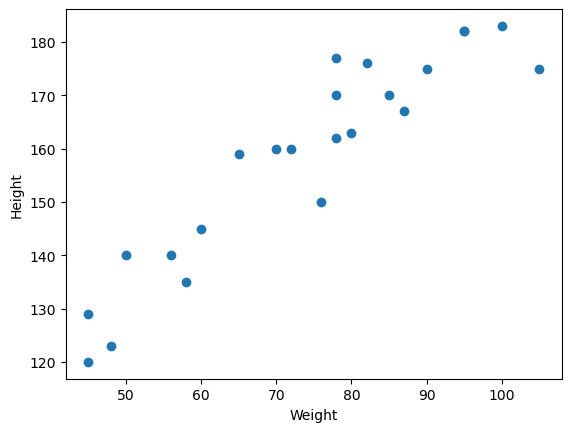

In [5]:
plt.scatter(df['Weight'],df["Height"])
plt.ylabel("Height")
plt.xlabel("Weight")

In [6]:
X=df[['Weight']]
y=df['Height']

In [7]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [8]:
X.shape,y.shape

((23, 1), (23,))

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [11]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [12]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

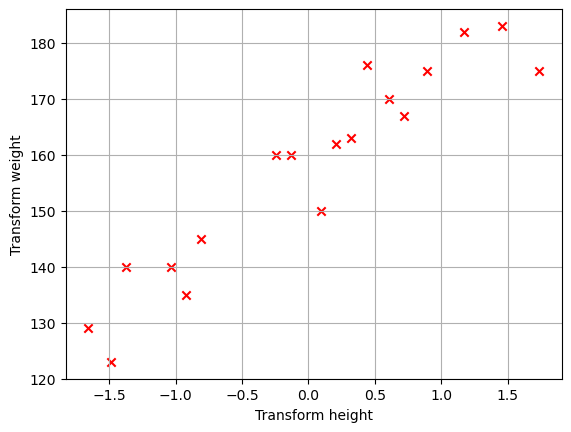

In [13]:
plt.scatter(X_train,y_train,c='r',marker='x')
plt.ylabel("Transform weight")
plt.xlabel("Transform height")
plt.grid()

In [14]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,y_train)
print("The coeficient or slope of weight is ",regressor.coef_)
print("Intercept:",regressor.intercept_)

The coeficient or slope of weight is  [17.03440872]
Intercept: 157.5


Text(0.5, 0, 'Weight')

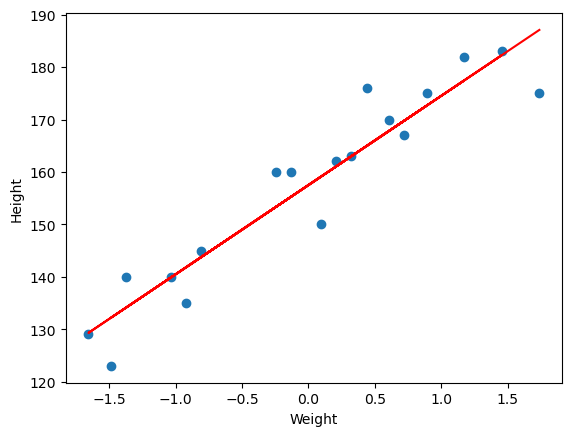

In [15]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')
plt.ylabel("Height")
plt.xlabel("Weight")

In [16]:
y_pred_test=regressor.predict(X_test)
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

Text(0.5, 0, 'Weight')

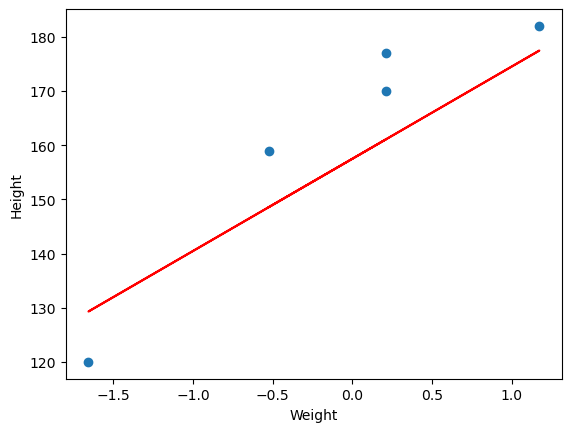

In [17]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')
plt.ylabel("Height")
plt.xlabel("Weight")

In [20]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print("Training loss for regression",mse)
print("On average the prediction is of by",mae)
print(rmse)

Training loss for regression 109.77592599051664
On average the prediction is of by 9.822657814519232
10.477400726827081


In [19]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)
score


0.776986986042344

In [21]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [26]:
scaled_weight=scaler.transform([[80]])
scaled_weight[0]

C:\Users\welcome\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0.32350772])

In [24]:
print("The height prediction for weight 80 kg is :",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is : [163.01076266]


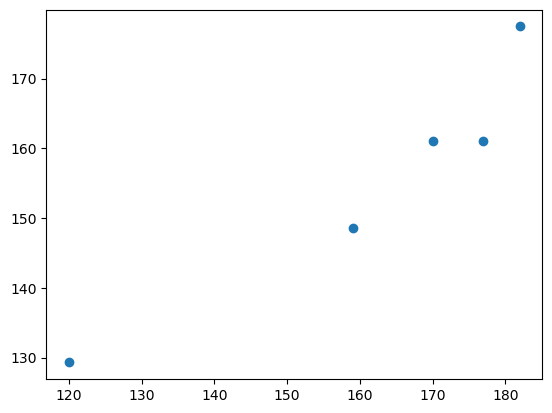

In [25]:
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [27]:
residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\welcome\AppData\Local\Temp\ipykernel_14548\3905197135.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

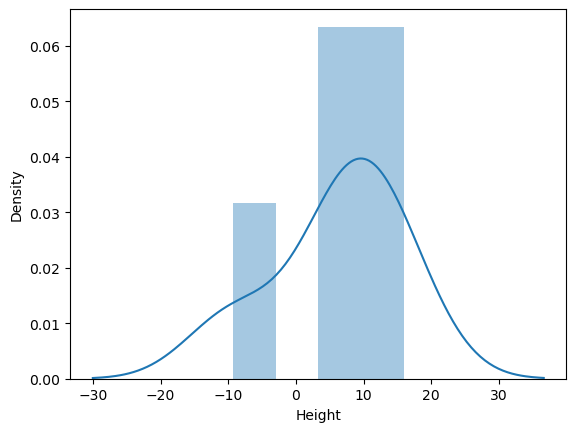

In [28]:
import seaborn as sns
sns.distplot(residuals,kde=True)

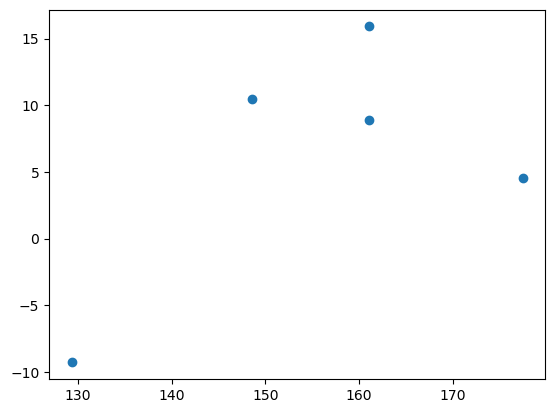

In [29]:

plt.scatter(y_pred_test,residuals)